In [1]:
import pandas as pd
from GNN.architecture import GNNTrainer
import torch
import pickle
from sklearn.metrics import ndcg_score
import numpy as np
import random
from numpy import unravel_index

## LOAD THE DATASET

In [2]:
train_data = pd.read_csv("data/movielens/train.csv", index_col=0)
val_data = pd.read_csv("data/movielens/test.csv", index_col=0)
movie_features = pd.read_csv("data/movielens/movie_features.csv", index_col=0)
train_pair_data = np.loadtxt("data/movielens/train_pair.csv", dtype=np.int64, delimiter=",")
val_pair_data = np.loadtxt("data/movielens/val_pair.csv", dtype=np.int64, delimiter=",")


/tmp/ipykernel_2043270/1152477808.py:4: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_pair_data = np.loadtxt("data/movielens/train_pair.csv", dtype=np.int64, delimiter=",")
/tmp/ipykernel_2043270/1152477808.py:5: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      flo

## NEGATIVE SAMPLING - FOR 1 POSITVE SAMPLE THERE WILL BE 100 NEGATIVE SAMPLES

In [3]:
all_users = set(train_data['userId'].unique())
all_items = set(train_data['productId'].unique())

In [4]:
users_negative_samples = {}
for i,u in enumerate(all_users):
    user_u_positive_items = set(train_data[train_data['userId']==u]['productId'].unique())
    user_u_negative_items = all_items.difference(user_u_positive_items)
    users_negative_samples[u] = user_u_negative_items

In [5]:
all_pairs = []
for i ,(userId, productId_pos, _, _) in enumerate(train_data.values):
    sample_negative_items = random.sample(list(users_negative_samples[userId]), 100)
    pair_data_u = [[userId, productId_pos, userId, productId_neg] for productId_neg in sample_negative_items]
    all_pairs.extend(pair_data_u)
    if (i+1) % 1000 == 0:
        print(f"{i+1} records complete")

1000 records complete
2000 records complete
3000 records complete
4000 records complete
5000 records complete
6000 records complete
7000 records complete
8000 records complete
9000 records complete
10000 records complete
11000 records complete
12000 records complete
13000 records complete
14000 records complete
15000 records complete
16000 records complete
17000 records complete
18000 records complete
19000 records complete
20000 records complete
21000 records complete
22000 records complete
23000 records complete
24000 records complete
25000 records complete
26000 records complete
27000 records complete
28000 records complete
29000 records complete
30000 records complete
31000 records complete
32000 records complete
33000 records complete
34000 records complete
35000 records complete
36000 records complete
37000 records complete
38000 records complete
39000 records complete
40000 records complete
41000 records complete
42000 records complete
43000 records complete
44000 records comple

In [6]:
# SAVE PAIR DATA IN CSV FORMAT - userId, productId_pos, userId, productId_neg
all_pairs_np = np.array(all_pairs)

In [ ]:
np.savetxt("data/movielens/train_pair.csv", all_pairs_np, delimiter=",")

In [19]:
# Validation pair
all_users = set(val_data['userId'].unique())
all_items = set(val_data['productId'].unique())

In [20]:
users_negative_samples = {}
for i,u in enumerate(all_users):
    user_u_positive_items = set(val_data[val_data['userId']==u]['productId'].unique())
    user_u_negative_items = all_items.difference(user_u_positive_items)
    users_negative_samples[u] = user_u_negative_items

In [14]:
all_pairs = []
for i ,(userId, productId_pos, _, _) in enumerate(val_data.values):
    sample_negative_items = random.sample(list(users_negative_samples[userId]), 20)
    pair_data_u = [[userId, productId_pos, userId, productId_neg] for productId_neg in sample_negative_items]
    all_pairs.extend(pair_data_u)
    if (i+1) % 1000 == 0:
        print(f"{i+1} records complete")

1000 records complete
2000 records complete
3000 records complete
4000 records complete
5000 records complete
6000 records complete
7000 records complete
8000 records complete
9000 records complete
10000 records complete
11000 records complete
12000 records complete
13000 records complete
14000 records complete
15000 records complete
16000 records complete
17000 records complete
18000 records complete
19000 records complete
20000 records complete
21000 records complete
22000 records complete
23000 records complete
24000 records complete
25000 records complete
26000 records complete
27000 records complete
28000 records complete
29000 records complete
30000 records complete
31000 records complete
32000 records complete
33000 records complete
34000 records complete
35000 records complete
36000 records complete
37000 records complete
38000 records complete
39000 records complete
40000 records complete
41000 records complete
42000 records complete
43000 records complete
44000 records comple

In [26]:
all_pairs_np = np.array(all_pairs)

In [27]:
np.savetxt("data/movielens/val_pair.csv", all_pairs_np, delimiter=",")

## TRAINER - TRAIN FOR 10 EPOCHS

In [3]:
trainer = GNNTrainer(train_data, movie_features, train_pair_data, val_pair_data)

/home/arnabroy/Workspace/recommendation_system/GNN/architecture.py:187: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_movie_features.sort_index(inplace=True)


In [5]:
trainer.train_data

HeteroData(
  user={ x=[7964] },
  product={ x=[9725] },
  product_feature={ x=[9725, 20] },
  (user, rates, product)={ edge_index=[2, 698113] },
  (product, rated_by, user)={ edge_index=[2, 698113] }
)

Epoch 1, step 20 | BPR Loss - 3.4634761810302734
Epoch 1, step 40 | BPR Loss - 2.8366947174072266
Epoch 1, step 60 | BPR Loss - 3.0611751079559326
Epoch 1, step 80 | BPR Loss - 3.3492133617401123
Epoch 1, step 100 | BPR Loss - 2.606184959411621
Epoch 1, step 120 | BPR Loss - 2.3496689796447754
Epoch 1, step 140 | BPR Loss - 1.9636729955673218
Epoch 1, step 160 | BPR Loss - 2.354907274246216
Epoch 1, step 180 | BPR Loss - 1.7568756341934204
Epoch 1, step 200 | BPR Loss - 1.5663082599639893
Epoch 1, step 220 | BPR Loss - 1.2154691219329834
Epoch 1, step 240 | BPR Loss - 1.82520592212677
Epoch 1, step 260 | BPR Loss - 2.250612497329712
Epoch 1, step 280 | BPR Loss - 0.6110785007476807
Epoch 1, step 300 | BPR Loss - 1.1944053173065186
Epoch 1, step 320 | BPR Loss - 1.2403545379638672
Epoch 1, step 340 | BPR Loss - 1.0858988761901855
Epoch 1, step 360 | BPR Loss - 1.4096893072128296
Epoch 1, step 380 | BPR Loss - 1.9040381908416748
Epoch 1, step 400 | BPR Loss - 1.1396819353103638
Epoch 1, 

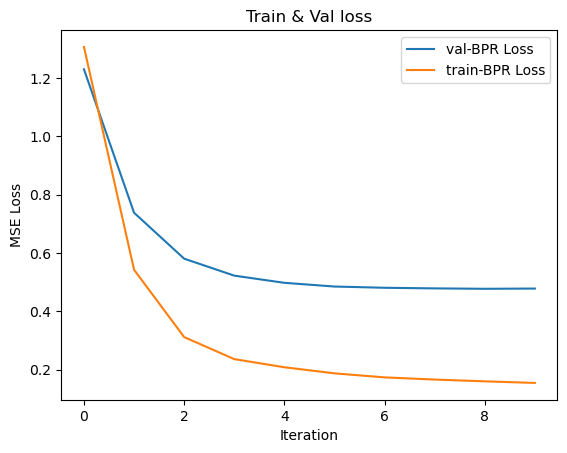

In [6]:
trainer.train(epochs=10, lr=0.0005, decay=10**(-4))

## MEASURE PERFORMANCE - OFFLINE NDCG 24.9%

In [7]:
val_df = pd.read_csv("data/movielens/test.csv", index_col=0)
val_df.head(3)

,userId,productId,rating,timestamp
20011489,195660,541,4.5,2022-10-17 16:31:56
20011492,195660,750,5.0,2022-10-17 16:32:12
20011523,195660,3504,5.0,2022-10-17 16:32:25


In [8]:
with open("models/GNN/best.pt", "rb") as f:
    model = torch.load(f)
    f.close()
with open("models/GNN/encoder.pkl", "rb") as f:
    enc = pickle.load(f)
    f.close()
model.to('cpu')
model.final_user_emb = model.final_user_emb.to('cpu')
model.final_item_emb = model.final_item_emb.to('cpu')

/tmp/ipykernel_2043270/4115498665.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f)


In [9]:
val_df['userId'] = val_df['userId'].map(lambda x: enc.user_id[x])
val_df['productId'] = val_df['productId'].map(lambda x: enc.item_id[x])
val_df.head(5)

,userId,productId,rating,timestamp
20011489,7959,44,4.5,2022-10-17 16:31:56
20011492,7959,867,5.0,2022-10-17 16:32:12
20011523,7959,2869,5.0,2022-10-17 16:32:25
27951262,7962,1386,4.0,2022-10-17 16:32:39
27951145,7962,1695,4.0,2022-10-17 16:32:44


In [10]:
gt_df = val_df.pivot(index='userId', columns='productId', values='rating').fillna(0.0)

In [11]:
all_users = gt_df.index.values
all_items = gt_df.columns.values

In [12]:
pred = torch.full(size=(gt_df.shape[0], gt_df.shape[1]),fill_value=0.0)

In [13]:
users_xx, items_yy = torch.meshgrid(torch.tensor(all_users) , torch.tensor(all_items))

/home/arnabroy/anaconda3/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1728945388038/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [14]:
for i in range(pred.shape[0]):
    users = users_xx[i]
    items = items_yy[i]
    ratings = model.predict(users, items)
    pred[i] = ratings

In [15]:
avg_ndcg = ndcg_score(gt_df.values, pred.detach().numpy())
avg_ndcg_20 = ndcg_score(gt_df.values, pred.detach().numpy(), k=20)

In [16]:
print(f"Offline NDCG average is {avg_ndcg*100: 0.2f}%")
print(f"Offline NDCG@20 is {avg_ndcg_20*100: 0.2f}%")


Offline NDCG average is  34.52%
Offline NDCG@20 is  8.13%


## EXPLORING REPRESENTATIONS

In [61]:
movies = pd.read_csv('data/movielens/movies.csv')
ratings = pd.read_csv('data/movielens/train.csv', index_col=0)

In [62]:
with open("models/GNN/best.pt", "rb") as f:
    model = torch.load(f)
    f.close()
with open("models/GNN/encoder.pkl", "rb") as f:
    enc = pickle.load(f)
    f.close()
model.to('cpu')
model.final_user_emb = model.final_user_emb.detach().cpu().numpy()
model.final_item_emb = model.final_item_emb.detach().cpu().numpy()

/tmp/ipykernel_2043270/3233660656.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f)


In [63]:
# MOST SIMILAR MOVIE PAIRS
movie_sim = model.final_item_emb@model.final_item_emb.T
np.fill_diagonal(movie_sim, -1)
max_pos = unravel_index(movie_sim.argmax(), movie_sim.shape)
movie_1, movie_2 = enc.id_item[max_pos[0]], enc.id_item[max_pos[1]]
print("Most similar movie pairs")
movies[movies['movieId'].isin([movie_1, movie_2])]

Most similar movie pairs


,movieId,title,genres
587,595,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX
15543,81847,Tangled (2010),Animation|Children|Comedy|Fantasy|Musical|Roma...


In [64]:
# Similar movie of any random movie
movie = enc.id_item[260]
print(movies[movies['movieId'].isin([movie])])
movies[movies['movieId'].isin([movie])]
top_10 = movie_sim[260].argsort()[::-1][:10]
top_10 = [enc.id_item[x] for x in top_10]
print('\nTop 10 similar movies of the above movie based on the viewing pattern')
movies[movies['movieId'].isin(top_10)]

      movieId                   title                  genres
1207     1240  Terminator, The (1984)  Action|Sci-Fi|Thriller

Top 10 similar movies of the above movie based on the viewing pattern


,movieId,title,genres
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
1166,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller
5338,5445,Minority Report (2002),Action|Crime|Mystery|Sci-Fi|Thriller
10681,44191,V for Vendetta (2006),Action|Sci-Fi|Thriller|IMAX
11976,56174,I Am Legend (2007),Action|Horror|Sci-Fi|Thriller|IMAX
12223,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
14939,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
21212,109487,Interstellar (2014),Sci-Fi|IMAX


In [65]:
user = enc.id_user[1048]
print(f"Top 10 rated movies by user {user} ")
df = ratings[ratings['userId'] == user].sort_values(by='rating', ascending=False)
df['movie'] = df['productId'].map(lambda x: movies[movies['movieId']==x]['title'].values[0])
df[['userId', 'movie', 'rating']].iloc[:10]

Top 10 rated movies by user 61485 


,userId,movie,rating
6303770,61485,The Bee Gees: How Can You Mend a Broken Heart ...,4.0
6302397,61485,Mad Max (1979),4.0
6302398,61485,"Road Warrior, The (Mad Max 2) (1981)",4.0
6303526,61485,Trick 'r Treat (2007),4.0
6303777,61485,Spider-Man: No Way Home (2021),4.0
6301861,61485,Conan the Barbarian (1982),4.0
6303778,61485,The Batman (2022),4.0
6303779,61485,Scream (2022),4.0
6301803,61485,Dracula (Bram Stoker's Dracula) (1992),4.0
6302431,61485,Pumpkinhead (1988),4.0


In [66]:
user = model.final_user_emb[1048].reshape((-1,1))
items = np.array(
    list(trainer.enc.id_item.keys()),
)
items = model.final_item_emb[items]
ratings = (items@user).flatten()
top_10 = np.argsort(ratings)[::-1][:10]

In [67]:
print(f"Top 10 movies recommended to the user {enc.id_user[1048]}")
for i in top_10:
    print(movies[movies['movieId']==trainer.enc.id_item[i]]['title'].values[0])

Top 10 movies recommended to the user 61485
Nope (2022)
X (2022)
The Black Phone (2022)
Morbius (2022)
Bodies Bodies Bodies (2022)
Scream (2022)
Hellraiser (1987)
Everything Everywhere All at Once (2022)
Day Shift (2022)
Hellraiser (2022)
